# Moment Criterion Non-Monotonicity Analysis

This notebook demonstrates and explains the non-monotonic behavior of the Moment
criterion, contrasting it with the guaranteed monotonicity of Spectral and Krylov.

**Key finding:** Adding operators to the Moment test can *break* an unreachability
certificate that existed at smaller K. This is mathematically real, not numerical noise.

**Runtime:** ~5-10 minutes

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from src.models import CanonicalQuditModel
from src.criteria import MomentCriterion, SpectralCriterion, KrylovCriterion, Verdict
from src.plotting import CRIT_COLORS

np.random.seed(42)

## 1. Concrete Non-Monotonic Example

Find a specific (model, target) pair where Moment finds an unreachability certificate
at K operators but *fails* at K+1 (using the first K+1 operators as a superset).

In [2]:
d = 16
model = CanonicalQuditModel(dim=d, seed=42)
phi = model.init_state()
rng = np.random.default_rng(123)

# Search for a concrete violation
example_found = False
for trial in range(200):
    K_max = 20
    sub = model.sample_submodel(K_max, seed=int(rng.integers(0, 2**31)))
    psi = sub.random_state(rng=rng)
    hams = np.stack(sub.basis)
    
    # Check Moment at each K
    verdicts = []
    for K in range(2, K_max + 1):
        mc = MomentCriterion(sub.basis[:K], phi, psi, tau=0.99)
        result = mc.is_reachable()
        verdicts.append(result.verdict == Verdict.UNREACHABLE)
    
    # Look for violation: True at K but False at K+1
    for i in range(len(verdicts) - 1):
        if verdicts[i] and not verdicts[i+1]:
            K_good = i + 2  # K where certificate exists
            K_bad = i + 3   # K+1 where it fails
            print(f"Found violation at trial {trial}: K={K_good} UNREACHABLE, K={K_bad} INCONCLUSIVE")
            print(f"Full verdict sequence (K=2..{K_max}):")
            for j, v in enumerate(verdicts):
                K = j + 2
                marker = '<-- violation' if j == i else ''
                print(f"  K={K:2d}: {'UNREACHABLE' if v else 'inconclusive':15s} {marker}")
            example_hams = hams
            example_psi = psi
            example_verdicts = verdicts
            example_found = True
            break
    if example_found:
        break

if not example_found:
    print("No violation found in 200 trials (rare at d=16, try different seed)")

Found violation at trial 0: K=2 UNREACHABLE, K=3 INCONCLUSIVE
Full verdict sequence (K=2..20):
  K= 2: UNREACHABLE     <-- violation
  K= 3: inconclusive    
  K= 4: inconclusive    
  K= 5: inconclusive    
  K= 6: inconclusive    
  K= 7: inconclusive    
  K= 8: inconclusive    
  K= 9: inconclusive    
  K=10: inconclusive    
  K=11: inconclusive    
  K=12: inconclusive    
  K=13: inconclusive    
  K=14: inconclusive    
  K=15: inconclusive    
  K=16: inconclusive    
  K=17: inconclusive    
  K=18: inconclusive    
  K=19: inconclusive    
  K=20: inconclusive    


## 2. Eigenvalue Visualization

Plot the eigenvalues of M(gamma) = Q + gamma * LL^T at each K to see how the
definiteness changes when operators are added.

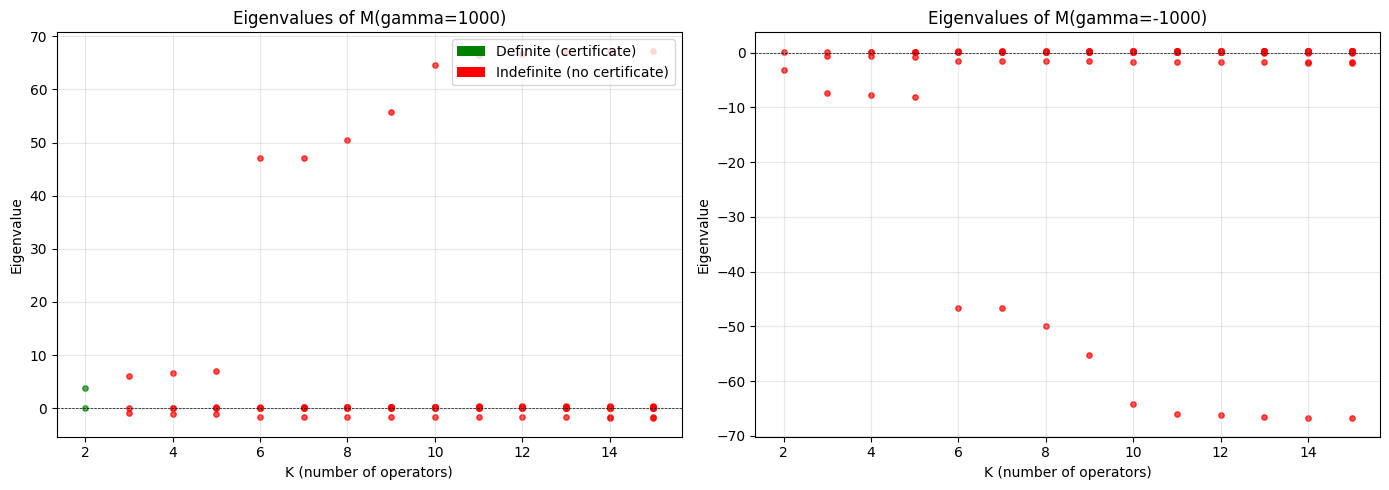

In [3]:
if example_found:
    K_range = range(2, min(16, len(example_hams) + 1))
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for gamma_idx, gamma in enumerate([1000.0, -1000.0]):
        ax = axes[gamma_idx]
        ax.set_title(f'Eigenvalues of M(gamma={gamma:.0f})')
        
        for K in K_range:
            hams_K = example_hams[:K]
            Hpsi = np.einsum('kij,j->ki', hams_K, example_psi)
            Hphi = np.einsum('kij,j->ki', hams_K, phi)
            L = np.real(np.einsum('d,kd->k', example_psi.conj(), Hpsi)
                        - np.einsum('d,kd->k', phi.conj(), Hphi))
            Q = 2 * (np.real(Hpsi.conj() @ Hpsi.T) - np.real(Hphi.conj() @ Hphi.T))
            M = Q + gamma * np.outer(L, L)
            eigvals = np.linalg.eigvalsh(M)
            
            color = 'green' if np.all(eigvals > 1e-10) or np.all(eigvals < -1e-10) else 'red'
            ax.scatter([K] * len(eigvals), eigvals, c=color, s=15, alpha=0.7)
        
        ax.axhline(y=0, color='k', linewidth=0.5, linestyle='--')
        ax.set_xlabel('K (number of operators)')
        ax.set_ylabel('Eigenvalue')
        ax.grid(True, alpha=0.3)
    
    # Custom legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='green', label='Definite (certificate)'),
                       Patch(facecolor='red', label='Indefinite (no certificate)')]
    axes[0].legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    plt.savefig('../fig/moment_eigenvalues.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Skipped (no example found)")

## 3. Statistical Non-Monotonicity

Paired test: for each (submodel, target), evaluate Moment at K and K+1 where the
K+1 operators are a superset of the K operators. Count how often K finds a certificate
but K+1 does not.

In [4]:
d = 16
model = CanonicalQuditModel(dim=d, seed=42)
phi = model.init_state()
K_values = list(range(2, 21))
n_hamiltonians = 30
n_targets = 10
n_trials = n_hamiltonians * n_targets

counts = {K: 0 for K in K_values}
violations = {K: 0 for K in K_values[:-1]}
rng = np.random.default_rng(42)

for h in range(n_hamiltonians):
    K_max = max(K_values)
    sub = model.sample_submodel(K_max, seed=int(rng.integers(0, 2**31)))
    hams = np.stack(sub.basis)
    
    for t in range(n_targets):
        psi = sub.random_state(rng=rng)
        Hpsi = np.einsum('kij,j->ki', hams, psi)
        Hphi = np.einsum('kij,j->ki', hams, phi)
        
        v = {}
        for K in K_values:
            L = np.real(np.einsum('d,kd->k', psi.conj(), Hpsi[:K])
                        - np.einsum('d,kd->k', phi.conj(), Hphi[:K]))
            Q = 2 * (np.real(Hpsi[:K].conj() @ Hpsi[:K].T)
                     - np.real(Hphi[:K].conj() @ Hphi[:K].T))
            L_outer = np.outer(L, L)
            
            found = False
            for gamma in [1000.0, -1000.0]:
                M = Q + gamma * L_outer
                eigvals = np.linalg.eigvalsh(M)
                if np.all(eigvals > 1e-10) or np.all(eigvals < -1e-10):
                    found = True
                    break
            v[K] = found
            if found:
                counts[K] += 1
        
        for i, K in enumerate(K_values[:-1]):
            K_next = K_values[i + 1]
            if v[K] and not v[K_next]:
                violations[K] += 1

print(f"Paired Moment Test: d={d}, {n_trials} trials")
print(f"{'K':>4}  {'P(unreach)':>10}  {'violations':>10}  {'%':>6}")
print("-" * 36)
for K in K_values:
    P = counts[K] / n_trials
    v = violations.get(K, 0)
    pct = f"{v/n_trials*100:.1f}" if K in violations else "-"
    print(f"{K:4d}  {P:10.3f}  {v:10d}  {pct:>6}")

total = sum(violations.values())
print(f"\nTotal paired violations: {total} ({total/n_trials*100:.1f}% of trials)")

Paired Moment Test: d=16, 300 trials
   K  P(unreach)  violations       %
------------------------------------
   2       0.953          87    29.0
   3       0.663          43    14.3
   4       0.520          22     7.3
   5       0.447          13     4.3
   6       0.403           0     0.0
   7       0.403          20     6.7
   8       0.337           0     0.0
   9       0.337           0     0.0
  10       0.337          10     3.3
  11       0.303          21     7.0
  12       0.233           0     0.0
  13       0.233           0     0.0
  14       0.233           0     0.0
  15       0.233          20     6.7
  16       0.167           0     0.0
  17       0.167          20     6.7
  18       0.100           0     0.0
  19       0.100           0     0.0
  20       0.100           0       -

Total paired violations: 256 (85.3% of trials)


## 4. Comparison: Moment vs Spectral/Krylov Monotonicity

Run all three criteria on the same trials and compare monotonicity behavior.
Spectral and Krylov are guaranteed monotonic (any violation is optimizer noise);
Moment violations are mathematically real.

  K=4... 

M=0.76, S=1.00, K=1.00
  K=6... 

M=0.35, S=1.00, K=1.00
  K=8... 

M=0.50, S=1.00, K=0.93
  K=10... 

M=0.30, S=1.00, K=0.88
  K=12... 

M=0.10, S=1.00, K=0.43
  K=14... 

M=0.05, S=1.00, K=0.35
  K=16... 

M=0.05, S=0.99, K=0.16
  K=18... 

M=0.05, S=0.96, K=0.17
  K=20... 

M=0.05, S=0.80, K=0.07


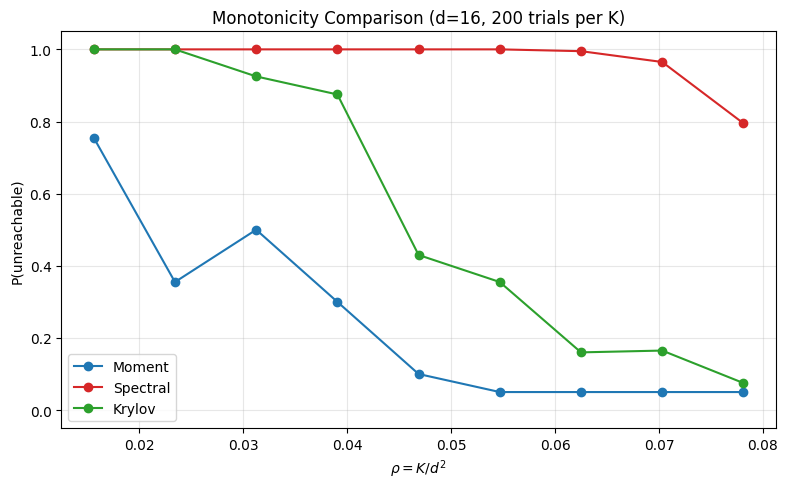

moment    : NON-MONOTONIC (1 increases > 0.02)
spectral  : monotonic (0 increases > 0.02)
krylov    : monotonic (0 increases > 0.02)


In [5]:
d = 16
model = CanonicalQuditModel(dim=d, seed=42)
phi = model.init_state()
K_values = [4, 6, 8, 10, 12, 14, 16, 18, 20]
n_hamiltonians = 20
n_targets = 10
n_trials = n_hamiltonians * n_targets

P_data = {c: [] for c in ['moment', 'spectral', 'krylov']}
rng = np.random.default_rng(42)

for K in K_values:
    counts = {'moment': 0, 'spectral': 0, 'krylov': 0}
    print(f"  K={K}...", end=" ", flush=True)
    
    for h in range(n_hamiltonians):
        sub = model.sample_submodel(K, seed=int(rng.integers(0, 2**31)))
        
        for t in range(n_targets):
            psi = sub.random_state(rng=rng)
            
            mc = MomentCriterion(sub, phi, psi, tau=0.99)
            if mc.is_reachable().verdict == Verdict.UNREACHABLE:
                counts['moment'] += 1
            
            sc = SpectralCriterion(sub, phi, psi, tau=0.99)
            if sc.is_reachable(maxiter=50, restarts=3).verdict == Verdict.UNREACHABLE:
                counts['spectral'] += 1
            
            kc = KrylovCriterion(sub, phi, psi, tau=0.99, m=d)
            if kc.is_reachable(maxiter=50, restarts=3).verdict == Verdict.UNREACHABLE:
                counts['krylov'] += 1
    
    for c in counts:
        P_data[c].append(counts[c] / n_trials)
    print(f"M={P_data['moment'][-1]:.2f}, S={P_data['spectral'][-1]:.2f}, K={P_data['krylov'][-1]:.2f}")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
rho_values = [K / d**2 for K in K_values]

for crit in ['moment', 'spectral', 'krylov']:
    ax.plot(rho_values, P_data[crit], 'o-', color=CRIT_COLORS[crit],
            label=crit.capitalize(), markersize=6)

ax.set_xlabel(r'$\rho = K/d^2$')
ax.set_ylabel('P(unreachable)')
ax.set_title(f'Monotonicity Comparison (d={d}, {n_trials} trials per K)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig('../fig/moment_vs_spectral_krylov.png', dpi=150, bbox_inches='tight')
plt.show()

# Check monotonicity
for crit in ['moment', 'spectral', 'krylov']:
    violations = sum(1 for i in range(len(P_data[crit])-1)
                     if P_data[crit][i+1] > P_data[crit][i] + 0.02)
    status = 'NON-MONOTONIC' if violations > 0 else 'monotonic'
    print(f"{crit:10s}: {status} ({violations} increases > 0.02)")

## 5. Mathematical Explanation

### Why Spectral/Krylov are monotonic

Both criteria compute $\max_{\lambda \in \mathbb{R}^K} S(\lambda)$ where $S$ is a
non-negative score. Adding an operator $H_{K+1}$ expands the feasible set from
$\mathbb{R}^K$ to $\mathbb{R}^{K+1}$. The old maximum is still achievable (set
$\lambda_{K+1} = 0$), so:

$$\max_{\lambda \in \mathbb{R}^{K+1}} S(\lambda) \geq \max_{\lambda \in \mathbb{R}^K} S(\lambda)$$

This means if $\max S < \tau$ at $K$ operators (UNREACHABLE), it remains $< \tau$ at
$K+1$... unless the optimizer fails to find the global maximum.

### Why Moment is NOT monotonic

The Moment criterion tests definiteness of $M(\gamma) = Q + \gamma LL^T$ where:
- $L_k = \langle H_k \rangle_\psi - \langle H_k \rangle_\phi$ (K-vector)
- $Q_{km} = \langle \{H_k, H_m\} \rangle_\psi - \langle \{H_k, H_m\} \rangle_\phi$ (K×K matrix)

Adding $H_{K+1}$ changes $Q$ from $K \times K$ to $(K+1) \times (K+1)$, introducing
new cross-terms. The definiteness of $M$ depends on the eigenvalue structure of the
entire matrix, not just the submatrix — a new row/column can flip a previously definite
matrix to indefinite.

This is analogous to how a $2 \times 2$ positive definite matrix can become indefinite
when extended to $3 \times 3$ if the new off-diagonal terms are large enough.

## Summary

| Property | Spectral/Krylov | Moment |
|----------|----------------|--------|
| What is optimized | $\max_\lambda$ score | None (direct check) |
| Monotonicity in K | Guaranteed | Not guaranteed |
| Source of noise | Optimizer convergence | Mathematical (eigenvalue structure) |
| Appropriate fit | Fermi-Dirac | No monotonic fit |

**Implications:**
1. Do not fit Moment data with monotonic functions
2. Use Spectral/Krylov for quantitative phase transition analysis
3. Moment is a fast, useful screening tool — non-monotonicity only affects cross-K comparisons